# The characterization of T cells in ENKTCL (Figure S6)

**Manuscript Context:** This notebook contains the code and workflows used to generate **Figure S6a-h** for our study on Extranodal NK/T-cell lymphoma (ENKTCL).

**Objective:**
The goal of this analysis is to provide a comprehensive characterization of the T cell compartment, dissecting their heterogeneity, functional states, and clonal dynamics in the context of ENKTCL. Specifically, we:
1. Visualize the distribution and proportion of distinct T cell subtypes across individual samples.
2. Identify key transcriptional differences between specific T cell subsets (pTex_CD39 vs. Tcm_XCL1; Tex_CD8 vs. Tex_CD4) using volcano plots.
3. Assess the expression dynamics of exhaustion and activation markers (ZNF683, CD38, LAG3, GZMB) under different treatment statuses.
4. Investigate pathway-level changes (HallMark 2020) in response to Immune Checkpoint Inhibitor (ICI) treatment within specific T cell states (Trm_ZNF683 and Tex_CD4).
5. Analyze the clonal size distribution of naive and central memory CD8⁺ T cells to infer clonal expansion.
6. Reconstruct the developmental trajectory of T cell substates using pseudotemporal ordering.


In [1]:
import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import numpy as np
import muon as mu
import scirpy as ir
from scipy import stats
import matplotlib as mpl
import matplotlib.ticker as ticker
import sys
import os
mpl.rcParams['font.family'] = 'Arial'
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 14
print(sys.version)

3.11.11 (main, Dec 11 2024, 16:28:39) [GCC 11.2.0]


In [2]:
figPath = "./figures/figS6"
TPath = './data/NKTCL_T.h5ad'
irPath = './data/NKTCL-ir.h5ad'
CD8TPath = './data/NKTCL_CD8T.h5ad'
CD4TPath = './data/NKTCL_CD4T.h5ad'
datPath = "./data/NKTCL_concat.h5ad"
os.makedirs(figPath, exist_ok=True)

In [3]:
adata_T = sc.read_h5ad(TPath)
adata_CD4T = sc.read_h5ad(CD4TPath)
adata_CD8T = sc.read_h5ad(CD8TPath)
nktcl_ir = sc.read_h5ad(irPath)

/home/rzh/miniconda3/lib/python3.11/site-packages/anndata/utils.py:362: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)


#### **Fig. S6a** Stacked bar plots show T cell Subtype proportions across samples.

In [4]:
def propPlot(age_df, barlabels, ax, colors=sc.pl.palettes.default_20, xlabel='Patient ID', show_y=True, xrotate=90):
    all_df = age_df.sum(axis=1)
    age_normdf = pd.DataFrame([age_df.loc[i,:]/all_df[i] for i in barlabels], index=barlabels)
    age_cumdf = pd.DataFrame([np.cumsum(age_normdf.loc[i,:]) for i in barlabels], index=barlabels)
    norm_gdfs = age_normdf
    cum_gdfs = age_cumdf
    for i, col in enumerate(age_df.columns):
        height = norm_gdfs[col]
        starts = cum_gdfs[col] - height
        rects = ax.barh(barlabels, height, left=starts, height=0.9, color=colors[i], edgecolor='white', linewidth=0.5,
                        label=col, alpha=1)
    
        # ax.bar_label(rects,age_df.loc[:, col], label_type='center', color='lightgrey', fontsize=14)
    ax.legend( bbox_to_anchor=(1, 0), 
              handletextpad=0.5, frameon=False,
                          borderpad=0.4,
                          columnspacing=1,
                          handlelength=0.65,
              loc='lower left')
    if show_y:
        ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1,decimals=0))
        ax.set_xlabel('Cell proportions')
    else:
        ax.yaxis.set_visible(False)
    ax.set_ylabel(xlabel)
    # ax.set_yticks(barlabels)
    # ax.set_xticklabels(labels=barlabels,rotation=xrotate)
    ax.spines.top.set_visible(False)
    ax.spines.right.set_visible(False)

/tmp/ipykernel_2393299/1909312482.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_yticklabels(['P01_0', 'P02_0', 'P03_0', 'P04_0','P05_0',


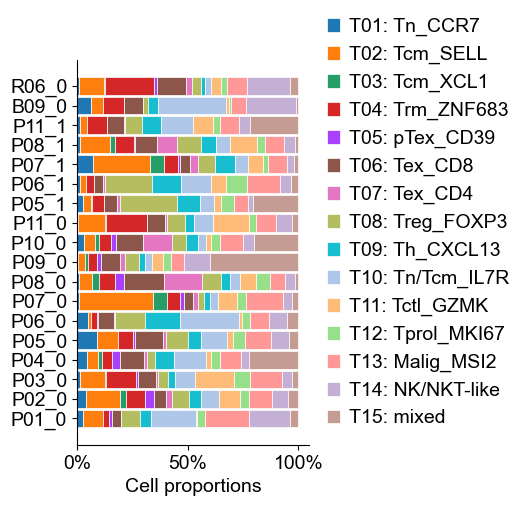

In [6]:
barlabels = [ 'NK1_0', 'NK2_0', 'NK3_0', 'NK4_0','NK5_0', 
             'NK6_0','NK7_0',  'NK8_0', 'NK9_0','NK10_0', 
             'NK11_0','NK5_1', 'NK6_1','NK7_1', 'NK8_1',
             'NK11_1', 'PB9_0', 'RR6_0']
cell_types = list(adata_T.obs['CellStateLabels'].unique())
cell_types.sort()
age_df = pd.DataFrame(columns = list(cell_types))
for bar in barlabels:
    d1 = pd.DataFrame([len(adata_T[(adata_T.obs["CellStateLabels"] == ct) & (adata_T.obs["batch"] == bar)]) for ct in list(cell_types)], index = list(cell_types), columns=[bar]).T
    age_df = pd.concat([age_df, d1])
fig0, ax0 = plt.subplots(figsize=(3, 5))
propPlot(age_df, ax=ax0, barlabels=barlabels, xlabel='', show_y=True)
ax0.set_yticklabels(['P01_0', 'P02_0', 'P03_0', 'P04_0','P05_0', 
             'P06_0','P07_0',  'P08_0', 'P09_0','P10_0', 
             'P11_0','P05_1', 'P06_1','P07_1', 'P08_1',
             'P11_1', 'B09_0', 'R06_0'])
fig0.savefig(f"{figPath}/FigS6a.pdf",bbox_inches='tight')

#### **Fig. S6b** Volcano plots illustrate differentially expressed genes for key T cell subset comparisons. (Comparison of pTex_CD39 (T05) versus Tcm_XCL1 (T03))

In [4]:
import memento

def DE_memento_1d(adata: ad.AnnData, ctleft: list, ctright: list, groupby='annotation'):
  _adata = adata[adata.obs[groupby].isin(ctleft + ctright)].copy()
  _adata = ad.AnnData(_adata.layers['Raw'], obs = _adata.obs, var = _adata.var)
  _adata.obs['stim'] = _adata.obs[groupby].isin(ctright)
  _adata.obs['stim'] = _adata.obs['stim'].astype('int')
  _adata.obs['capture_rate'] = 0.07
  memento.setup_memento(_adata, q_column='capture_rate')
  memento.create_groups(_adata, label_columns=['stim'])
  memento.compute_1d_moments(_adata, min_perc_group=.7)
  meta_df = memento.get_groups(_adata)
  meta_df['intercept'] = 1
  convariate = meta_df[['intercept']]
  treatment = (meta_df[['stim']] == 1).astype(float)
  
  memento.ht_1d_moments(_adata,
  covariate=convariate,
  treatment=treatment,
  num_cpus=16,
  resample_rep=False,
  )
  memento_results = memento.get_1d_ht_result(_adata)
  return(memento_results)

In [5]:
ctleft = ['T03: Tcm_XCL1']
ctright = [ 'T05: pTex_CD39']
pTex_degs = DE_memento_1d(adata_T, 
                         ctleft = ctleft, 
                         ctright = ctright, 
                         groupby='CellStateLabels')

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    3.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    4.7s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    7.6s
[Parallel(n_jobs=16)]: Done 768 tasks      | elapsed:   11.6s
[Parallel(n_jobs=16)]: Done 1218 tasks      | elapsed:   16.8s
[Parallel(n_jobs=16)]: Done 1768 tasks      | elapsed:   22.8s
[Parallel(n_jobs=16)]: Done 2418 tasks      | elapsed:   30.4s
[Parallel(n_jobs=16)]: Done 3168 tasks      | elapsed:   38.9s
[Parallel(n_jobs=16)]: Done 4018 tasks      | elapsed:   47.7s
[Parallel(n_jobs=16)]: Done 4968 tasks      | elapsed:   58.2s
[Parallel(n_jobs=16)]: Done 6018 tasks      | elapsed:  1.2min
[Parallel(n_jobs=16)]: Done 7168 tasks      | elapsed:  1.4min
[Parallel(n_jobs=16)]: Done 7718 out of 7718 | elapsed:  1.5min finished


In [6]:
import anndata2ri
import rpy2.rinterface_lib.callbacks
import logging
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

In [7]:
%load_ext rpy2.ipython
anndata2ri.set_ipython_converter()

In [8]:
%%R -i pTex_degs
library(ggVolcano)
library(RColorBrewer)
library(ggsci)
data <- add_regulate(pTex_degs, log2FC_name = "de_coef",
                     fdr_name = "de_pval",log2FC = 0.4, fdr = 0.05)
# plot
p <- ggvolcano(data, x = "log2FoldChange", y = "padj",
          label = "gene", label_number = 20,
          output = FALSE, legend_position = "UR",
          log2FC_cut = 0.4, FDR_cut = 1e-5) +
    labs(x="correlation", y="-log P-value")
ggsave("./figures/figS6/FigS6b.pdf", p, width = 3.2, height = 4, units = "in")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.5.1
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loading required package: tidyverse


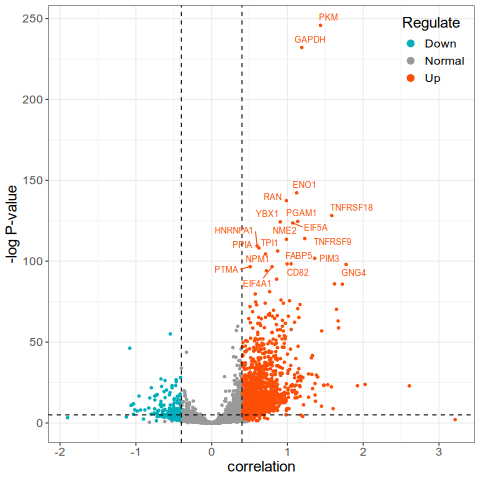

In [9]:
%%R
print(p)

#### **Fig. S6c** Volcano plots illustrate differentially expressed genes for key T cell subset comparisons. (Comparison of Tex_CD8 (T06) versus Tex_CD4 (T07))

In [15]:
ctleft = ['T07: Tex_CD4']
ctright = ['T06: Tex_CD8']
Tex_degs = DE_memento_1d(adata_T, 
                         ctleft = ctleft, 
                         ctright = ctright, 
                         groupby='CellStateLabels')

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 304 tasks      | elapsed:    2.6s
[Parallel(n_jobs=16)]: Done 804 tasks      | elapsed:    6.6s
[Parallel(n_jobs=16)]: Done 1504 tasks      | elapsed:   12.4s
[Parallel(n_jobs=16)]: Done 2404 tasks      | elapsed:   20.0s
[Parallel(n_jobs=16)]: Done 3504 tasks      | elapsed:   29.1s
[Parallel(n_jobs=16)]: Done 4804 tasks      | elapsed:   40.0s
[Parallel(n_jobs=16)]: Done 6304 tasks      | elapsed:   52.5s
[Parallel(n_jobs=16)]: Done 6888 out of 6888 | elapsed:   57.1s finished


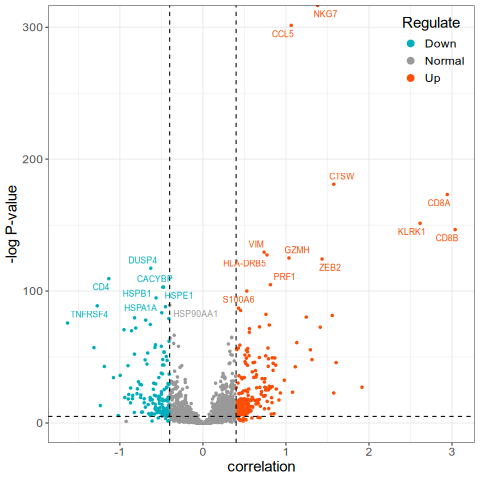

In [16]:
%%R -i Tex_degs
library(ggVolcano)
library(RColorBrewer)
library(ggsci)
data <- add_regulate(Tex_degs, log2FC_name = "de_coef",
                     fdr_name = "de_pval",log2FC = 0.4, fdr = 0.05)
# plot
p <- ggvolcano(data, x = "log2FoldChange", y = "padj",
          label = "gene", label_number = 20,
          output = FALSE, legend_position = "UR",
          log2FC_cut = 0.4, FDR_cut = 1e-5) +
    labs(x="correlation", y="-log P-value")
ggsave("./figures/figS6/FigS6c.pdf", p, width = 3.2, height = 4, units = "in")
print(p)

#### **Fig. S6d** Scaled expression of ZNF683, CD38, LAG3, and GZMB in different treatment status. 
Statistical significance was determined using the two-sided Kruskal-Wallis test. Subsequently, post-hoc pairwise comparisons were performed using the two-sided Wilcoxon rank-sum test. P-values were adjusted for multiple testing using the Benjamini-Hochberg method.

In [984]:
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd

def Gexplot_adata(adata, gene, ax, group='treatment'):
    # Set the visual theme for the plot
    sns.set_style("ticks")
    
    # Extract data based on whether the gene is in .obs (metadata) or .var_names (expression matrix)
    if gene in adata.obs.columns:
        data = adata.obs[[gene, group]]
    elif gene in adata.var_names:
        data = adata.obs[[group]]
        # Extract expression values from the matrix (handle sparse matrices)
        data[gene] = np.array(adata[:, gene].X.todense()).flatten()
    else:
        raise ValueError(f"{gene} not found in .obs or .var_names.")
    
    # Generate the violin plot
    sc.pl.violin(adata, keys=[gene], groupby=group, width=.6, ax=ax, show=False)
    
    # Prepare data for statistical testing
    groups = data.groupby(group).agg(list)
    group_names = list(data[group].unique())
    
    # Perform One-way ANOVA to compare means across groups
    f_statistic, pval = stats.f_oneway(groups.loc[group_names[0], gene], 
                                       groups.loc[group_names[1], gene])
    
    # Determine significance stars based on p-value
    if pval < 0.001:
        star = '***'
    elif pval < 0.01:
        star = '**'
    elif pval < 0.05:
        star = '*'
    else:
        star = 'ns'
        
    # Check if the result is statistically significant
    alpha = 0.05
    if pval < alpha:
        print("Reject the null hypothesis; at least one group mean is significantly different.")
        # Perform Tukey's HSD post-hoc test for pairwise comparisons
        tukey = pairwise_tukeyhsd(endog=data[gene], groups=data[group], alpha=alpha)
        print("\nTukey's HSD Post-hoc Test Results:")
        print(tukey)
    else:
        print("Fail to reject the null hypothesis; no significant difference in group means.")
        
    # Adjust plot aesthetics (limits and annotations)
    ax.set_ylim(min(data[gene]) - 0.05, max(data[gene] + 0.3))
    
    # Draw a significance bracket line above the violins
    sns.lineplot(x=[1, 2], y=max(data[gene]) + 0.3, color='black', linewidth=1.2, ax=ax)
    
    # Add text annotation for F-statistic and p-value
    ax.text(1.5, max(data[gene]) + 0.3, 
            f"ANOVA F={f_statistic:.3f}, p={pval:.2e}\n{star}", 
            fontsize=12, horizontalalignment='center')
            
    # Remove top and right spines for a cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    return ax

/tmp/ipykernel_3335451/4116333582.py:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Reject the null hypothesis; at least one group mean is significantly different.

Tukey's HSD Post-hoc Test Results:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  PBMC   Post  -0.0504 0.0004  -0.083 -0.0178   True
  PBMC    Pre  -0.0221 0.2725 -0.0535  0.0094  False
  PBMC   Recu   0.0897    0.0  0.0558  0.1235   True
  Post    Pre   0.0284    0.0  0.0149  0.0419   True
  Post   Recu   0.1401    0.0  0.1218  0.1585   True
   Pre   Recu   0.1117    0.0  0.0955   0.128   True
----------------------------------------------------


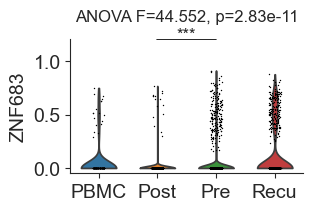

In [985]:
fig, ax = plt.subplots(1,1, figsize=(3,1.75))
ax = Gexplot_adata(adata_CD8T[adata_CD8T.obs['CellStateLabels'].isin(['T04: Trm_ZNF683'])], 'ZNF683', ax=ax, group='treatment')
ax.set_xlabel('')
fig.savefig(f"{figPath}/FigS6d-ZNF683.pdf", bbox_inches='tight')

/tmp/ipykernel_3335451/4116333582.py:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Reject the null hypothesis; at least one group mean is significantly different.

Tukey's HSD Post-hoc Test Results:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
  PBMC   Post    0.097 0.0001  0.038 0.1559   True
  PBMC    Pre   0.2573    0.0 0.1998 0.3147   True
  PBMC   Recu   0.3301    0.0 0.2659 0.3942   True
  Post    Pre   0.1603    0.0 0.1419 0.1787   True
  Post   Recu   0.2331    0.0 0.1991 0.2671   True
   Pre   Recu   0.0728    0.0 0.0414 0.1041   True
--------------------------------------------------


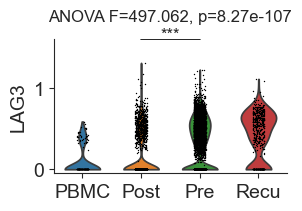

In [986]:
fig, ax = plt.subplots(1,1, figsize=(3, 1.75))
ax = Gexplot_adata(adata_CD8T[adata_CD8T.obs['CellStateLabels'].isin(['T05: pTex_CD39', 'T06: Tex_CD8', 'T07: Tex_CD4'])], 'LAG3', ax=ax, group='treatment')
ax.set_xlabel('')
fig.savefig(f"{figPath}/FigS6d-LAG3.pdf", bbox_inches='tight')

/tmp/ipykernel_3335451/4116333582.py:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Reject the null hypothesis; at least one group mean is significantly different.

Tukey's HSD Post-hoc Test Results:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  PBMC   Post   0.0164 0.8059 -0.0305  0.0633  False
  PBMC    Pre   0.1581    0.0  0.1124  0.2038   True
  PBMC   Recu   0.0789 0.0004  0.0279    0.13   True
  Post    Pre   0.1417    0.0  0.1271  0.1564   True
  Post   Recu   0.0626    0.0  0.0355  0.0896   True
   Pre   Recu  -0.0792    0.0 -0.1041 -0.0542   True
----------------------------------------------------


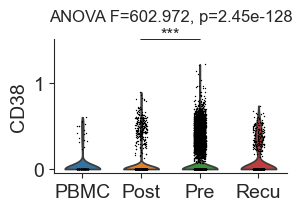

In [987]:
fig, ax = plt.subplots(1,1, figsize=(3, 1.75))
ax = Gexplot_adata(adata_CD8T[adata_CD8T.obs['CellStateLabels'].isin(['T05: pTex_CD39', 'T06: Tex_CD8', 'T07: Tex_CD4'])], 'CD38', ax=ax, group='treatment')
ax.set_xlabel('')
fig.savefig(f"{figPath}/FigS6d-CD38.pdf", bbox_inches='tight')

/tmp/ipykernel_3335451/4116333582.py:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Reject the null hypothesis; at least one group mean is significantly different.

Tukey's HSD Post-hoc Test Results:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  PBMC   Post    -0.17    0.0 -0.2167 -0.1233   True
  PBMC    Pre  -0.0361 0.1722 -0.0814  0.0093  False
  PBMC   Recu   0.2652    0.0  0.2154  0.3149   True
  Post    Pre   0.1339    0.0  0.1174  0.1504   True
  Post   Recu   0.4352    0.0  0.4089  0.4615   True
   Pre   Recu   0.3012    0.0  0.2775   0.325   True
----------------------------------------------------


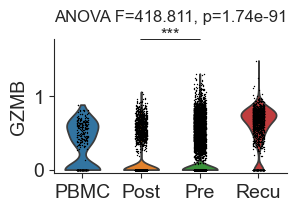

In [988]:
fig, ax = plt.subplots(1,1, figsize=(3, 1.75))
ax = Gexplot_adata(adata_CD8T[adata_CD8T.obs['CellStateLabels'].isin(['T04: Trm_ZNF683','T05: pTex_CD39', 'T06: Tex_CD8', 'T07: Tex_CD4'])], 'GZMB', ax=ax, group='treatment')
ax.set_xlabel('')
fig.savefig(f"{figPath}/FigS6d-GZMB.pdf", bbox_inches='tight')

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(3.5,1.75))
ax = Gexplot_adata(adata_CD8T[adata_CD8T.obs['CellStateLabels'].isin(['T05: Trm_ZNF683'])], 'CD38', ax=ax, group='treatment')
ax.set_xlabel('')
fig.savefig(f"{figPath}/FigS6d-ZNF683.pdf", bbox_inches='tight')

#### **Fig. S6e** The top 10 enrichment pathways of pre-ICI versus post-ICI samples in T04: Trm_ZNF683

In [1006]:
import gseapy as gp
from gseapy import Msigdb

def prep_enrichr(adata, groupby):
  """
  Prepares differential expression results for enrichment analysis.
  
  This function performs differential expression analysis using Scanpy's 
  rank_genes_groups method and organizes the results into a structured 
  DataFrame. It extracts gene names, scores, p-values, and log fold changes 
  for all groups, formatting them for downstream enrichment analysis.
  
  Parameters:
  -----------
  adata : AnnData
      The annotated AnnData object containing the single-cell data.
  groupby : str
      The key in adata.obs that defines the groups for comparison.
      
  Returns:
  --------
  pandas.DataFrame
      A DataFrame containing differential expression results with columns 
      formatted as 'group_key' (e.g., 'cluster_names', 'cluster_pvals').
  """
  # de analysis
  sc.tl.rank_genes_groups(adata, groupby=groupby)
  sc.tl.dendrogram(adata, groupby=groupby)
  # get deg result
  result = adata.uns['rank_genes_groups']
  groups = result['names'].dtype.names
  degs = pd.DataFrame(
      {group + '_' + key: result[key][group]
      for group in groups for key in ['names','scores', 'pvals','pvals_adj','logfoldchanges']})
  return degs

def run_enrichr_genelist(genelist):
  """
  Performs enrichment analysis on a list of genes using multiple databases.
  
  This function runs enrichment analysis on the provided gene list using 
  five different gene set libraries: KEGG pathways, GO Cellular Component, 
  MSigDB Hallmark, GO Molecular Function, and GO Biological Process. It 
  returns the results from all five analyses for comprehensive functional 
  annotation.
  
  Parameters:
  -----------
  genelist : list
      A list of gene symbols to be analyzed for enrichment.
      
  Returns:
  --------
  tuple
      A tuple containing five enrichment result objects (KEGG, Cellular 
      Component, Hallmark, Molecular Function, Biological Process).
  """
  kegg = gp.enrichr(genelist,
                  gene_sets='KEGG_2021_Human',
                  outdir=None)
  cc = gp.enrichr(genelist,
                      gene_sets='GO_Cellular_Component_2023',
                      outdir=None)
  hm = gp.enrichr(genelist,
                      gene_sets=['MSigDB_Hallmark_2020'],
                      outdir=None)
  mf = gp.enrichr(genelist,
                      gene_sets='GO_Molecular_Function_2023',
                      outdir=None)
  bp = gp.enrichr(genelist,
                      gene_sets=['GO_Biological_Process_2023'],
                      outdir=None)
  return kegg, cc, hm, mf, bp

def run_enrichr_scanpy(degs, group,direction='up', top_term=15, all_term=False, plot=True):
  """
  Performs enrichment analysis on Scanpy differential expression results.
  
  This function filters differentially expressed genes based on adjusted 
  p-value and log fold change, then performs enrichment analysis on either 
  up-regulated or down-regulated genes. It combines results from multiple 
  databases and optionally generates a bar plot of the top enriched terms.
  
  Parameters:
  -----------
  degs : pandas.DataFrame
      DataFrame containing differential expression results from prep_enrichr.
  group : str
      The group name to analyze (e.g., 'cluster_0').
  direction : str, optional
      Either 'up' or 'down' to specify direction of regulation.
  top_term : int, optional
      Number of top enriched terms to display in the plot.
  all_term : bool, optional
      If True, returns all enriched terms instead of just the top ones.
  plot : bool, optional
      If True, generates a bar plot of enriched terms.
      
  Returns:
  --------
  tuple
      A tuple containing the enrichment results DataFrame and the plot axis 
      (or None if plot=False).
  """
  # subset up or down regulated genes
  degs_sig = degs[degs[f'{group}_pvals_adj'] < 0.05]
  degs_up = degs_sig[degs_sig[f'{group}_logfoldchanges'] > 0]
  degs_dw = degs_sig[degs_sig[f'{group}_logfoldchanges'] < 0]
  degs_used = degs_up[f'{group}_names'] if direction == 'up' else degs_dw[f'{group}_names']
  kegg, cc, hm, mf, bp = run_enrichr_genelist(degs_used)
  go_res = pd.concat([kegg.res2d.head(top_term),
                    hm.res2d.head(top_term), 
                    cc.res2d.head(top_term), 
                    bp.res2d.head(top_term), 
                    mf.res2d.head(top_term)])
  if plot:
    ax = gp.barplot(go_res, figsize=(6,20),
                group ='Gene_set',
                top_term=top_term,
                color = ['#8b9cc4', '#f08961', '#62bb9f', '#e71f19', '#3d5eaa'],
                title ="The Most Enriched Terms")
  else:
    ax = None
  if all_term:
    go_res = pd.concat([kegg.res2d, hm.res2d, cc.res2d, bp.res2d, mf.res2d])
  return go_res, ax
  
def run_enrichr_memento(memento_results,direction='up', top_term=15):
  """
  Performs enrichment analysis on Memento differential expression results.
  
  This function filters differentially expressed genes from Memento results 
  based on p-value and coefficient, then performs enrichment analysis on 
  either up-regulated or down-regulated genes. It combines results from 
  multiple databases and generates a bar plot of the top enriched terms.
  
  Parameters:
  -----------
  memento_results : pandas.DataFrame
      DataFrame containing differential expression results from Memento.
  direction : str, optional
      Either 'up' or 'down' to specify direction of regulation.
  top_term : int, optional
      Number of top enriched terms to display in the plot.
      
  Returns:
  --------
  tuple
      A tuple containing the enrichment results DataFrame and the plot axis.
  """
  memento_sig = memento_results[memento_results['de_pval'] < 0.05]
  memento_up = memento_sig[memento_sig['de_coef'] > 0]
  memento_dw = memento_sig[memento_sig['de_coef'] < 0]
  degs_used = memento_up['gene'] if direction == 'up' else memento_dw['gene']
  kegg, cc, hm, mf, bp = run_enrichr_genelist(degs_used)
  go_res = pd.concat([kegg.res2d.head(15),
                      hm.res2d.head(15), 
                      cc.res2d.head(15), 
                      bp.res2d.head(15), 
                      mf.res2d.head(15)])
  ax = gp.barplot(go_res, figsize=(6,20),
              group ='Gene_set',
              top_term=top_term,
              color = ['#8b9cc4', '#f08961', '#62bb9f', '#e71f19', '#3d5eaa'],
              title ="The Most Enriched Terms")
  return go_res, ax

In [1007]:
def HallMarkPlot(adata, anno, left, right, ct, left_label='Pre-ICI', right_label='Post-ICI', title=None):
  """
  Generates a comparative dot plot for Hallmark pathways between two treatment groups.
  
  This function performs enrichment analysis on two subsets of data (e.g., Pre-ICI 
  vs. Post-ICI) for a specific cell type. It identifies the top Hallmark pathways 
  enriched in each group, finds the intersection of these pathways, and visualizes 
  the enrichment status (significance and gene ratio) using a dot plot. This allows 
  for a direct visual comparison of how specific biological programs change between 
  conditions.
  
  Parameters:
  -----------
  adata : AnnData
      The input AnnData object containing the single-cell data.
  anno : str
      The key in adata.obs used for grouping (e.g., 'CellStateLabels').
  left : list
      List of treatment labels for the first group (e.g., ['Pre']).
  right : list
      List of treatment labels for the second group (e.g., ['Post']).
  ct : str
      The specific cell type/cluster label to analyze (e.g., 'T09: Th_CXCL13').
  left_label : str, optional
      Label for the x-axis corresponding to the 'left' group.
  right_label : str, optional
      Label for the x-axis corresponding to the 'right' group.
  title : str, optional
      Custom title for the plot. If None, the cell type 'ct' is used.
      
  Returns:
  --------
  tuple
      A tuple containing the filtered DataFrame with pathway enrichment results 
      and the matplotlib axis object for the generated dot plot.
  """
  degs_pre = prep_enrichr(adata[adata.obs['treatment'].isin(left)], anno)
  degs_post = prep_enrichr(adata[adata.obs['treatment'].isin(right) ], anno)
  print(f"Running enrichment for {left_label} {ct}...")
  go_pre, _ = run_enrichr_scanpy(degs_pre, ct,direction='up', top_term=15, all_term=True, plot=False)
  go_pre =  go_pre[['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Odds Ratio', 'Combined Score']]
  go_pre['anno'] = ct
  go_pre['treatment'] = 'left'

  print(f"Running enrichment for {right_label} {ct}...")
  go_post, _ = run_enrichr_scanpy(degs_post, ct,direction='up', top_term=15, all_term=True, plot=False)
  go_post = go_post[['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Odds Ratio', 'Combined Score']]
  go_post['anno'] = ct
  go_post['treatment'] = 'right'

  left_pathway = go_pre[go_pre['Gene_set'].isin(['MSigDB_Hallmark_2020'])][:10]['Term']
  right_pathway = go_post[go_post['Gene_set'].isin(['MSigDB_Hallmark_2020'])][:10]['Term']
  pathway = list(set(list(left_pathway)).intersection(list(right_pathway)))

  use_pathway_left = go_pre[go_pre['Gene_set'].isin(['MSigDB_Hallmark_2020'])]
  use_pathway_right = go_post[go_post['Gene_set'].isin(['MSigDB_Hallmark_2020'])]

  use_pathway_left = use_pathway_left[use_pathway_left['Term'].isin(left_pathway)]
  use_pathway_right = use_pathway_right[use_pathway_right['Term'].isin(right_pathway)]
  use_pathway = pd.concat([use_pathway_left, use_pathway_right], axis=0)
  ax = gp.dotplot(use_pathway,figsize=(2,5),
                x='treatment',
                title="",
                size=2.5,
                cmap='viridis',
                top_term=10,
                show_ring=True)
  ax.set_xticklabels(['Pre-ICI', 'Post-ICI'],rotation=0)
  ax.set_yticklabels(ax.get_yticklabels(),rotation=0,fontsize=11)
  ax.set_xlabel('')
  if title is None:
    ax.set_title(ct)
  else:
    ax.set_title(title)
  return use_pathway, ax

/home/rzh/miniconda3/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:667: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.

/home/rzh/miniconda3/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:667: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.



Running enrichment for Pre-ICI T04: Trm_ZNF683...
Running enrichment for Post-ICI T04: Trm_ZNF683...


/tmp/ipykernel_3335451/2941434295.py:68: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_3335451/2941434295.py:69: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



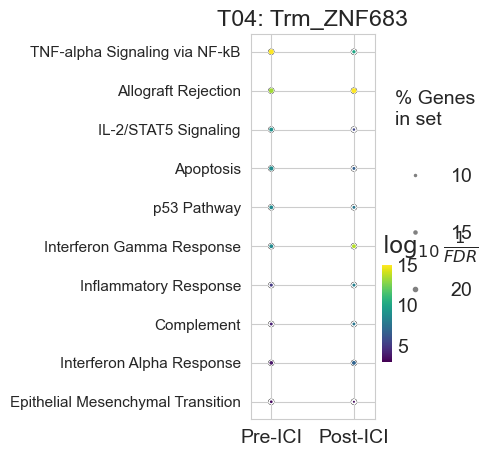

In [1008]:
use_pathway_Tex, ax_Tex = HallMarkPlot(adata_CD8T, 'CellStateLabels', ['Pre'], ['Post', 'PBMC'], 'T04: Trm_ZNF683', title='T04: Trm_ZNF683')
ax_Tex.figure.savefig(f"{figPath}/FigS6e-Trm.pdf", bbox_inches='tight')

#### **Fig. S6f** The top 10 enrichment pathways of pre-ICI versus post-ICI samples in T07: Tex_CD4
The dot size represents the proportion of highly expressed genes in the predefined gene sets. The color of the dots represents the negative log10 Benjamini–Hochberg FDR.

/home/rzh/miniconda3/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:667: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.

/home/rzh/miniconda3/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:667: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.



Running enrichment for Pre-ICI T07: Tex_CD4...
Running enrichment for Post-ICI T07: Tex_CD4...


/tmp/ipykernel_3335451/2941434295.py:68: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_3335451/2941434295.py:69: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



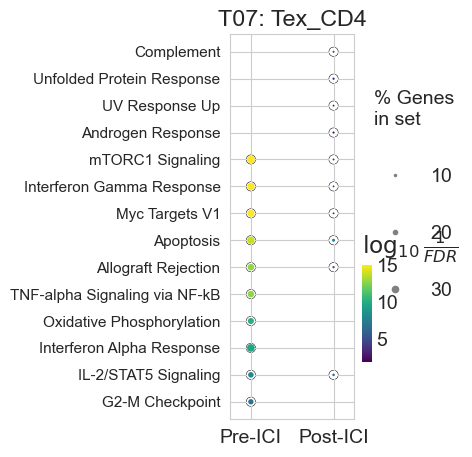

In [1009]:
use_pathway_Tex, ax_Tex = HallMarkPlot(adata_CD8T, 'CellStateLabels', ['Pre'], ['Post', 'PBMC'], 'T07: Tex_CD4', title='T07: Tex_CD4')
ax_Tex.figure.savefig(f"{figPath}/FigS6f-Tex.pdf", bbox_inches='tight')

#### **Fig. S6g** Clonal size distribution of naive (T01: Tn_CCR7, blue) and central memory (T02: Tcm_SELL, orange) CD8⁺ T cells. 
T02 exhibited a significantly higher proportion of large clones compared to T01 (p = 2.81×10⁻³, two-sided Wilcoxon test). Clone size categories are defined as ≤2, 3–5, 6–10, 11–20, 20–30, and ≥30 cells per clone.

=== Wilcoxon Rank-Sum Test (Mann-Whitney U) ===
T01 median: 3.0, n=1489
T02 median: 3.0, n=8111
U statistic: 5757837
P-value: 2.81e-03

✅ Conclusion: T02 has significantly larger clone sizes than T01 (**)


<Figure size 1000x600 with 0 Axes>

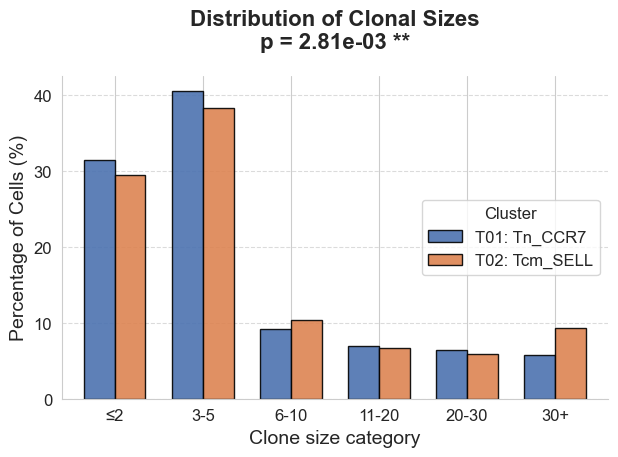

In [1005]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import pandas as pd
import numpy as np

# ==========================================
# 1. Data Preparation
# ==========================================

# Filter data for specific clusters (T01 and T02)
# Ensure 'spot_size' represents the clone size (numeric)
df_raw = adata_CD8T[adata_CD8T.obs['CellStateLabels'].isin(['T01: Tn_CCR7', 'T02: Tcm_SELL'])].obs[['CellStateLabels', 'spot_size']].dropna()
df_raw.columns = ['cluster', 'spot_size']

# Extract data for statistical testing
t01 = df_raw[df_raw['cluster'] == 'T01: Tn_CCR7']['spot_size']
t02 = df_raw[df_raw['cluster'] == 'T02: Tcm_SELL']['spot_size']

# ==========================================
# 2. Statistical Test (Wilcoxon / Mann-Whitney U)
# ==========================================
# Test if T02 clone sizes are significantly larger than T01
stat, p_value = mannwhitneyu(t01, t02) 

# Determine significance stars
if p_value < 0.001:
    sig_str = "***"
elif p_value < 0.01:
    sig_str = "**"
elif p_value < 0.05:
    sig_str = "*"
else:
    sig_str = "ns"

# Print results to console
print("=== Wilcoxon Rank-Sum Test (Mann-Whitney U) ===")
print(f"T01 median: {t01.median():.1f}, n={len(t01)}")
print(f"T02 median: {t02.median():.1f}, n={len(t02)}")
print(f"U statistic: {stat:.0f}")
print(f"P-value: {p_value:.2e}")
print(f"\n✅ Conclusion: T02 has significantly larger clone sizes than T01 ({sig_str})")

# ==========================================
# 3. Plotting: Grouped Bar Chart (Matching Reference Image)
# ==========================================

# Define the specific bin edges and labels to match the reference image
# Note: Adjust these bins based on your actual data distribution if necessary
bins = [0, 2, 3, 5, 10, 20, 30]
labels = ['≤2', '3-5', '6-10', '11-20', '20-30', '30+']

# Bin the continuous data into categories
df_raw['size_cat'] = pd.cut(df_raw['spot_size'], bins=bins, labels=labels, right=True)

# Calculate the percentage of cells in each category for each cluster
# crosstab gives counts, normalize='columns' converts them to percentages (sum to 100%)
df_pct = pd.crosstab(df_raw['size_cat'], df_raw['cluster'], normalize='columns') * 100

# Reorder index to ensure correct plotting order
df_pct = df_pct.reindex(labels)

# Setup the plot style
sns.set_style("whitegrid") # Similar to the dashed grid in the image
plt.figure(figsize=(10, 6))

# Create the grouped bar plot
# Using a palette similar to the image (Blue and Orange)
ax = df_pct.plot(kind='bar', 
                 color=['#4C72B0', '#DD8452'], # T01: Blue, T02: Orange
                 edgecolor='black', 
                 width=0.7, 
                 alpha=0.9)

# Customize the plot to match the reference image
plt.title(f'Distribution of Clonal Sizes\np = {p_value:.2e} {sig_str}', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Clone size category', fontsize=14)
plt.ylabel('Percentage of Cells (%)', fontsize=14)

# Rotate x-axis labels to be horizontal (as in image)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

# Customize Legend
plt.legend(title='Cluster', fontsize=12, title_fontsize=12, frameon=True, loc='center right')

# Add grid lines (dashed)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True) # Ensure grid is behind bars

# Remove top and right spines (cleaner look)
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.savefig(f"{figPath}/FigS6g.pdf", bbox_inches='tight')

#### **Fig. S6h** Graph visualization of T substates (left) and terminal clusters (right) defined by pseudotemporal ordering with staVIA.

**Environment Compatibility Note**

Running staVIA requires scipy==1.11.4, numpy==1.26.4, and dask==2026.3.0.

While cellphonedbV5 requies scipy>=1.12.0, which is not compatible with staVIA. 

Our default scipy version is 1.16.0. Therefore, **trajectory analysis using staVIA must be performed in an independent environment with the specified dependency versions**, and results are saved and loaded into the main analysis environment for visualization and downstream plotting.

This approach ensures full reproducibility while complying with the strict version constraints of each tool.

In [7]:
adata_subT = adata_T[~adata_T.obs['anno-subTfixed'].isin(['C14_NK/NKT_NCAM1', 'C15_mixed'])]
adata_subT = adata_subT[adata_subT.obs['batch'].isin(['NK11_0', 'NK11_1','NK5_0', 'NK5_1', 'NK6_0', 'NK6_1', 'NK7_0', 'NK7_1', 'NK8_0', 'NK8_1'])]
adata_subT

View of AnnData object with n_obs × n_vars = 34800 × 33727
    obs: 'batch', 'mt_frac', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes', 'n_counts', 'leiden-1', 'leiden-pca', 'anno-pca', 'treatment', 'leiden-T', 'annotation', 'cnv_status', 'cnv_score', 'exhaustion', 'cytotoxicity', 'anno-T', 'clonal_size', 'spot_size', 'CytoTRACE2_Score', 'CytoTRACE2_Potency', 'CytoTRACE2_Relative', 'preKNN_CytoTRACE2_Score', 'preKNN_CytoTRACE2_Potency', 'anno-subT', 'anno-Tfixed', 'anno-subTfixed', 'proliferation', 'anno-subT1', 'anno-focus', 'CellStateLabels', 'anno-NK', 'inflammation', 'stress'
    var: 'ID', 'name', 'type', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'CellStateLabels_colors', 'airr:chain_pairing_colors', 'airr:clonal_expansion_colors', 'airr:clone_id_colors', 'airr:receptor_subty

In [15]:
import pyVIA.core as via
#set parameters for Via 2.0
memory=100 #this is a high memory value and will result in probabilistic pathways that avoid transitioning into unrelated cell populations 
cluster_graph_pruning = 0.15 #level of pruning done on the cluster graph. higher number means less pruning (values can range from 0-3 standard deviations)
edgepruning_clustering_resolution = 0.15  # regulates number of clusters. Higher values means fewer clusters (values can range from 0-3 standard deviations)
random_seed = 1234 
knn = 30  # number of neighbors in the knn graph
knn_sequential = 15  # number of neighbors additionally created between sequentially adjacent time points 
n_pcs = 10 # number of principal components
velo_weight = 0  # 0.7 #weight given to velocity based direction compared to pseudotime based direction
t_diff_step = 1 #edges extending between nodes that are more than 2 time steps apart will be removed (i.e. equal to 3 or more time steps apart)
root = ['T01: Tn_CCR7'] #for reproducibility, we set the root here. the group level root assignment must correspond to a label that exists in the True-label parameter (must be passed inside a list). For autodetection based on rna-velocity it can be left as None. A single cell index can also be passed e.g. [256], means the 256th cell will be used as a root. Since we will be using the velocity matrices (see below), Via 2.0 will suggest a list of likely root cell states that the user can decide to choose between. It is helpful to examine the top 5 suggested roots and choose the one that seems most reasonable. Note in the output that Via 2.0's suggestions are almost all in the epibliast or Primitive streak state 
neighboring_terminal_states_threshold = 4
max_visual_outgoing_edges = 10#5 #used in differentiation flow chart plots
time_series = True
parc_numeric_cluster_labels = [i for i in adata_subT.obs['leiden-T']]
cluster_celltype_label = [i for i in adata_subT.obs['CellStateLabels']]
use_velocity = False
velo_weight = 0.5

if use_velocity:
    gene_matrix =np.asmatrix(adata_subT.layers['Ms'])
    velocity_matrix = np.asmatrix(adata_subT.layers['velocity'])
    velo_weight=velo_weight
else: 
    gene_matrix =None
    velocity_matrix = None
    velo_weight=0
vT = via.VIA(adata_subT.obsm['X_pca_harmony'][:, 0:n_pcs], true_label = cluster_celltype_label,
        edgepruning_clustering_resolution=edgepruning_clustering_resolution,
        edgepruning_clustering_resolution_local=1, knn=knn, memory=memory,
        root_user=root, random_seed=random_seed,
        knn_sequential_reverse=knn_sequential,
        gene_matrix=gene_matrix, velocity_matrix=velocity_matrix,
        velo_weight=velo_weight,
        )

In [16]:
from datetime import datetime
print(f'{datetime.now()}\tRun Via2.0')
vT.run_VIA()
print(f'{datetime.now()}\tEnd Via2.0 computation')

2026-04-15 15:46:15.671767	Run Via2.0
2026-04-15 15:46:15.671947	Running VIA over input data of 34800 (samples) x 10 (features)
2026-04-15 15:46:15.671982	Knngraph has 30 neighbors
2026-04-15 15:46:25.096926	Finished global pruning of 30-knn graph used for clustering at level of 0.15. Kept 48.6 % of edges. 
2026-04-15 15:46:25.276469	Number of connected components used for clustergraph  is 1
2026-04-15 15:46:27.061144	Commencing community detection
2026-04-15 15:46:32.744086	Finished community detection. Found 50 clusters.
2026-04-15 15:46:32.754574	Merging 33 very small clusters (<10)
2026-04-15 15:46:32.760087	Finished detecting communities. Found 17 communities
2026-04-15 15:46:32.762110	Making cluster graph. Global cluster graph pruning level: 0.15
2026-04-15 15:46:32.866364	Graph has 1 connected components before pruning
2026-04-15 15:46:32.868177	Graph has 1 connected components after pruning
2026-04-15 15:46:32.868333	Graph has 1 connected components after reconnecting
2026-04-1

/home/rzh/miniconda3/lib/python3.11/site-packages/pyVIA/core.py:176: UserWarning: WARNING: Implicitly set node IDs to the canonical node ordering due to missing IDs field in the raw CSR npz file. This warning message can be suppressed by setting implicit_ids to True in the read_npz function call, or by setting the --implicit_ids flag in the CLI
  g.set_node_ids(node_ids=None,


  0%|          | 0/1300 [00:00<?, ?it/s]

memory for rw2 hittings times  2. Using rw2 based pt
2026-04-15 15:46:38.374279	Identifying terminal clusters corresponding to unique lineages...
2026-04-15 15:46:38.374313	Closeness:[0, 2, 4, 5, 9, 11, 12, 15]
2026-04-15 15:46:38.374325	Betweenness:[2, 3, 4, 6, 7, 12, 13, 14, 16]
2026-04-15 15:46:38.374333	Out Degree:[0, 4, 5, 6, 8, 9, 11, 12, 15, 16]
2026-04-15 15:46:38.374505	Cluster 0 had 3 or more neighboring terminal states [5, 9, 11, 12] and so we removed cluster 12
2026-04-15 15:46:38.374530	We removed cluster 2 from the shortlist of terminal states
2026-04-15 15:46:38.374551	Cluster 4 had 3 or more neighboring terminal states [9, 15, 16] and so we removed cluster 15
2026-04-15 15:46:38.374570	Cluster 5 had 3 or more neighboring terminal states [0, 9, 11, 16] and so we removed cluster 11
2026-04-15 15:46:38.374592	Cluster 9 had 3 or more neighboring terminal states [0, 4, 5] and so we removed cluster 0
2026-04-15 15:46:38.374741	Terminal clusters corresponding to unique lineage

/home/rzh/miniconda3/lib/python3.11/site-packages/pyVIA/core.py:176: UserWarning: WARNING: Implicitly set node IDs to the canonical node ordering due to missing IDs field in the raw CSR npz file. This warning message can be suppressed by setting implicit_ids to True in the read_npz function call, or by setting the --implicit_ids flag in the CLI
  g.set_node_ids(node_ids=None,


  0%|          | 0/1000 [00:00<?, ?it/s]

2026-04-15 15:46:43.374140	Cluster or terminal cell fate 4 is reached 857.0 times
2026-04-15 15:46:43.402513	Cluster or terminal cell fate 5 is reached 301.0 times
2026-04-15 15:46:43.426762	Cluster or terminal cell fate 6 is reached 754.0 times
2026-04-15 15:46:43.456531	Cluster or terminal cell fate 9 is reached 101.0 times
2026-04-15 15:46:43.483033	Cluster or terminal cell fate 16 is reached 862.0 times
2026-04-15 15:46:43.519719	There are (5) terminal clusters corresponding to unique lineages {4: 'T13: Malig_MSI2', 5: 'T10: Tn/Tcm_IL7R', 6: 'T02: Tcm_SELL', 9: 'T09: Th_CXCL13', 16: 'T13: Malig_MSI2'}
2026-04-15 15:46:43.519800	Begin projection of pseudotime and lineage likelihood
2026-04-15 15:46:44.517501	Cluster graph layout based on forward biasing
2026-04-15 15:46:44.518688	Starting make edgebundle viagraph...
2026-04-15 15:46:44.518721	Make via clustergraph edgebundle
2026-04-15 15:46:44.689016	Hammer dims: Nodes shape: (17, 2) Edges shape: (94, 3)
2026-04-15 15:46:44.689914	

/home/rzh/miniconda3/lib/python3.11/site-packages/scipy/sparse/_index.py:100: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


/home/rzh/miniconda3/lib/python3.11/site-packages/pyVIA/plotting_via.py:3696: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  group_frac[ii][group_i] = true_label_in_group_i.count(ii)


2026-04-15 15:46:44.778012	Plot Via2.0 cluster graph


/home/rzh/miniconda3/lib/python3.11/site-packages/pyVIA/plotting_via.py:3702: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sct = ax.scatter(node_pos[:, 0], node_pos[:, 1],


tune edges False


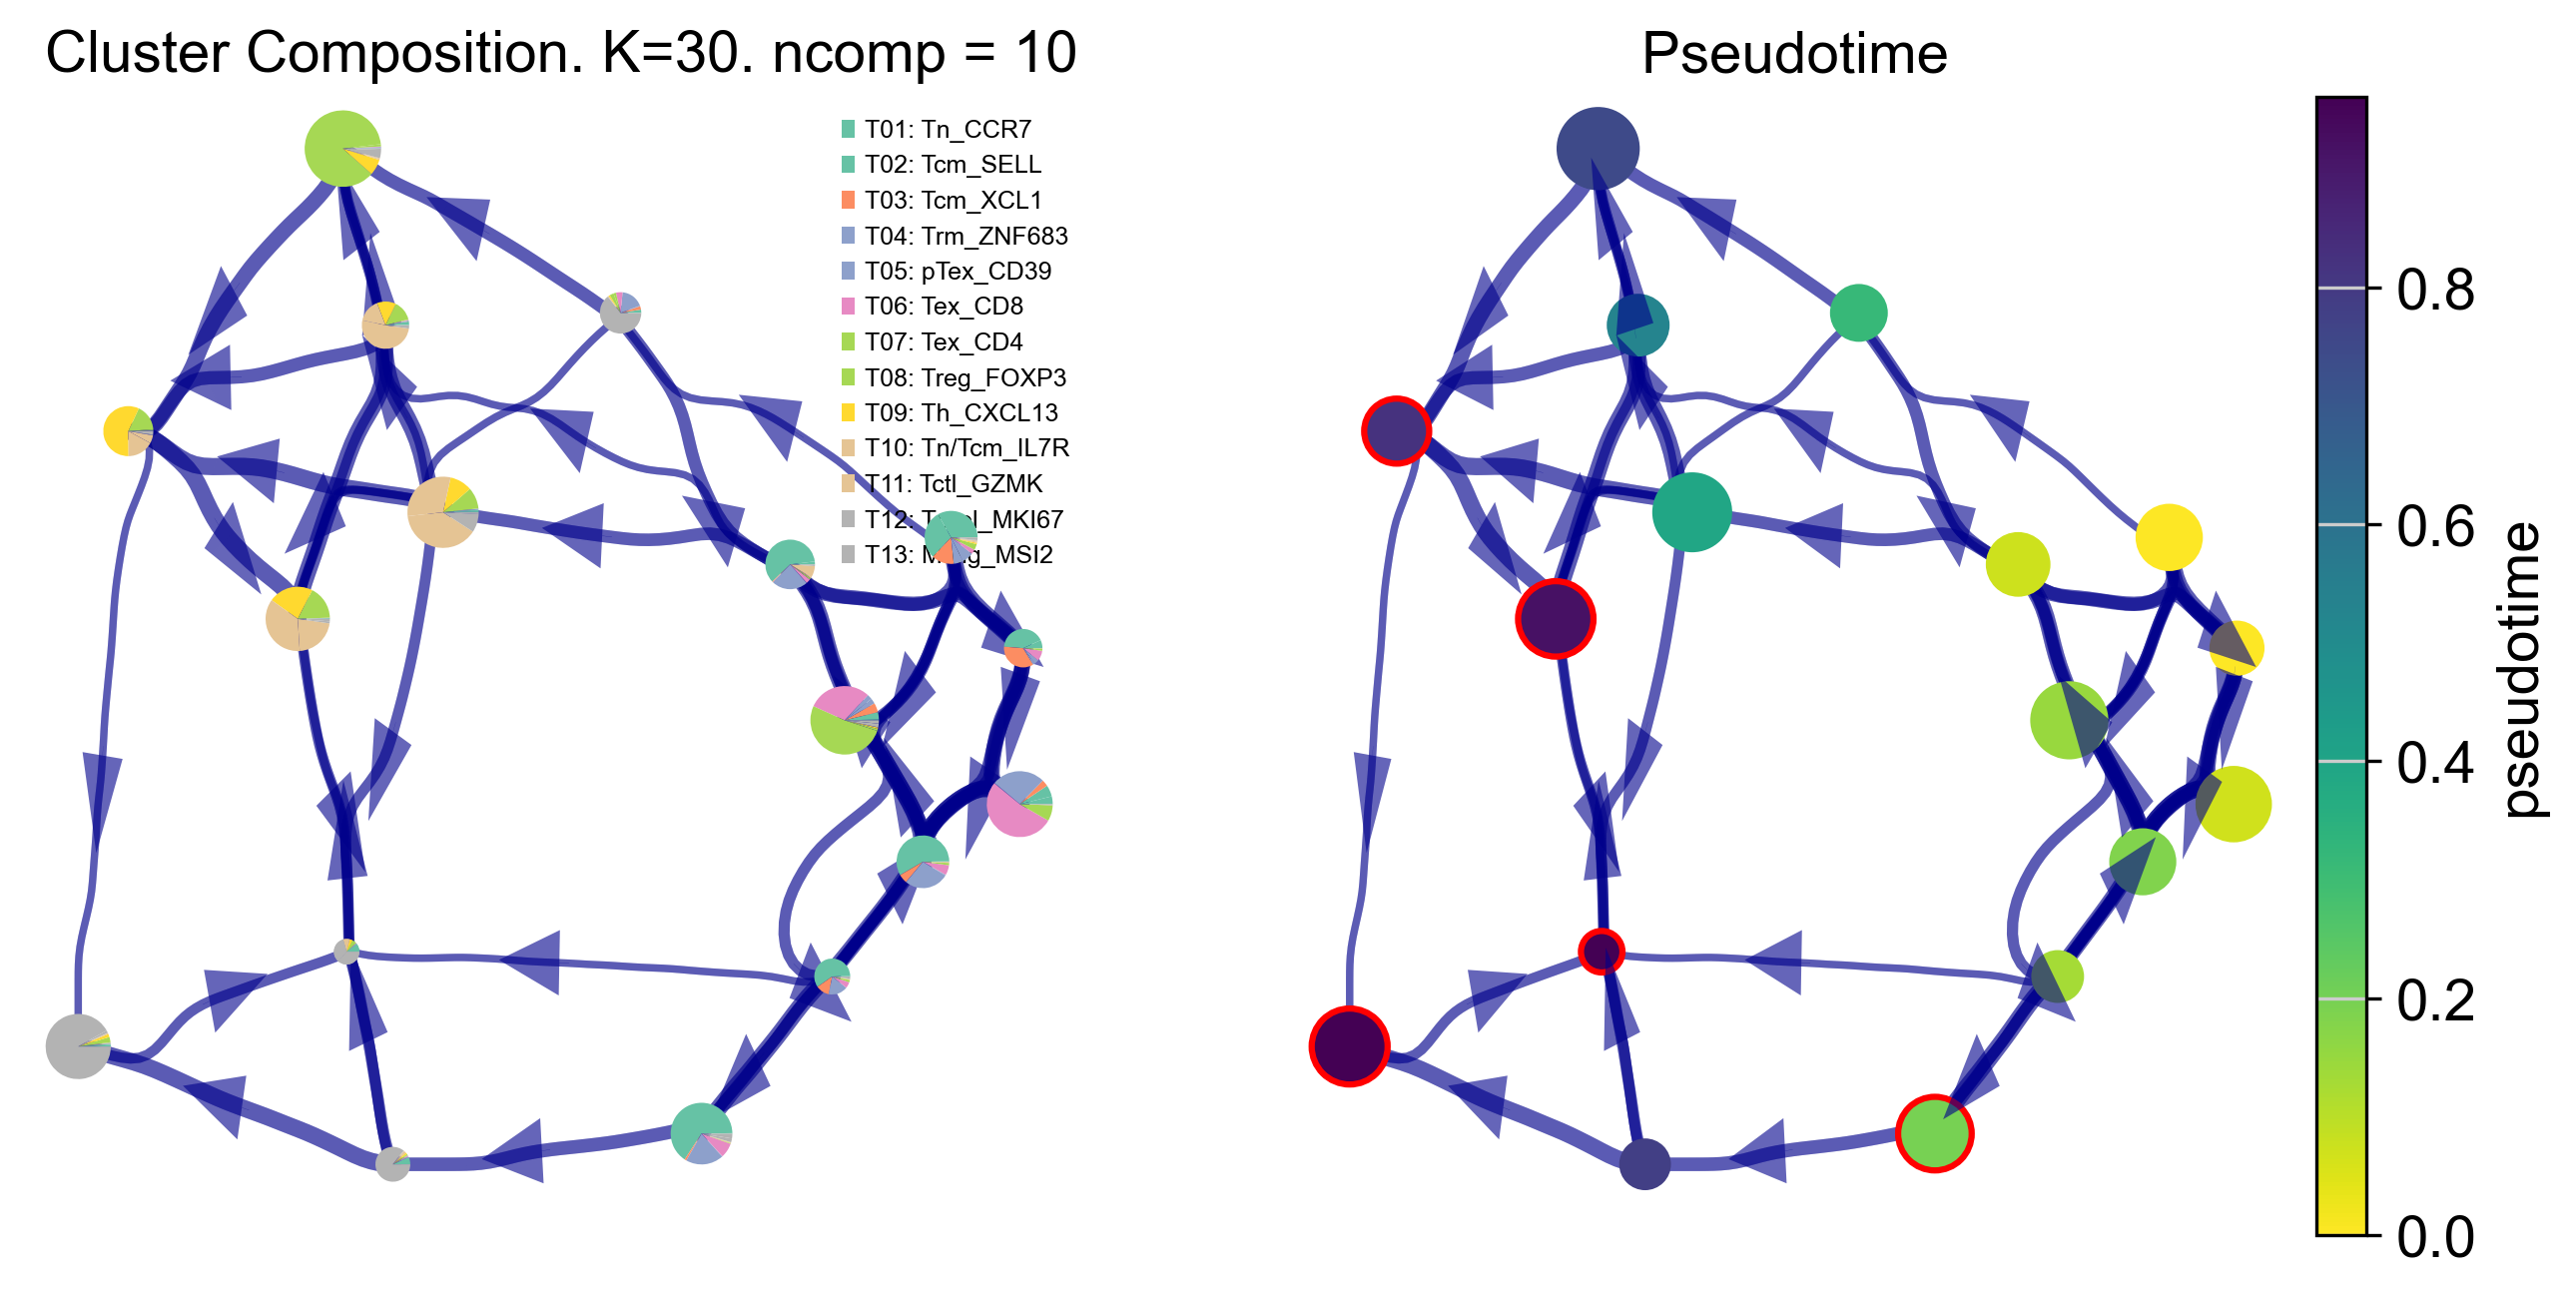

In [17]:
print(f'{datetime.now()}\tPlot Via2.0 cluster graph')
f, ax, ax1=via.plot_piechart_viagraph(via_object=vT, headwidth_arrow=0.2, show_legend=True, ax_text=False, pie_size_scale=0.6, cmap_piechart='Set2', 
                        highlight_terminal_clusters=True, size_node_notpiechart=0.8)
f.set_size_inches(10, 5)
f.savefig(f'{figPath}/FigS6h.pdf')

2026-04-15 15:54:33.672285	Run Via2.0
2026-04-15 15:54:33.672420	Running VIA over input data of 18021 (samples) x 10 (features)
2026-04-15 15:54:33.672435	Knngraph has 30 neighbors
2026-04-15 15:54:38.461773	Finished global pruning of 30-knn graph used for clustering at level of 0.15. Kept 48.4 % of edges. 
2026-04-15 15:54:38.565233	Number of connected components used for clustergraph  is 1
2026-04-15 15:54:39.479194	Commencing community detection
2026-04-15 15:54:42.298678	Finished community detection. Found 29 clusters.
2026-04-15 15:54:42.304061	Merging 13 very small clusters (<10)
2026-04-15 15:54:42.308120	Finished detecting communities. Found 16 communities
2026-04-15 15:54:42.309249	Making cluster graph. Global cluster graph pruning level: 0.15
2026-04-15 15:54:42.357522	Graph has 1 connected components before pruning
2026-04-15 15:54:42.359348	Graph has 1 connected components after pruning
2026-04-15 15:54:42.359508	Graph has 1 connected components after reconnecting
2026-04-1

/home/rzh/miniconda3/lib/python3.11/site-packages/pyVIA/core.py:176: UserWarning: WARNING: Implicitly set node IDs to the canonical node ordering due to missing IDs field in the raw CSR npz file. This warning message can be suppressed by setting implicit_ids to True in the read_npz function call, or by setting the --implicit_ids flag in the CLI
  g.set_node_ids(node_ids=None,


  0%|          | 0/1300 [00:00<?, ?it/s]

memory for rw2 hittings times  2. Using rw2 based pt
2026-04-15 15:54:47.833468	Identifying terminal clusters corresponding to unique lineages...
2026-04-15 15:54:47.833504	Closeness:[0, 4, 5, 6, 9, 11, 12]
2026-04-15 15:54:47.833518	Betweenness:[1, 2, 4, 6, 7, 8, 9, 10, 14]
2026-04-15 15:54:47.833526	Out Degree:[0, 4, 5, 6, 7, 9, 12, 13]
2026-04-15 15:54:47.833720	Cluster 5 had 3 or more neighboring terminal states [4, 6, 12] and so we removed cluster 12
2026-04-15 15:54:47.833880	Terminal clusters corresponding to unique lineages in this component are [0, 4, 5, 6, 7, 9] 
2026-04-15 15:54:47.833902	Calculating lineage probability at memory 100


/home/rzh/miniconda3/lib/python3.11/site-packages/pyVIA/core.py:176: UserWarning: WARNING: Implicitly set node IDs to the canonical node ordering due to missing IDs field in the raw CSR npz file. This warning message can be suppressed by setting implicit_ids to True in the read_npz function call, or by setting the --implicit_ids flag in the CLI
  g.set_node_ids(node_ids=None,


  0%|          | 0/1000 [00:00<?, ?it/s]

2026-04-15 15:54:52.621992	Cluster or terminal cell fate 0 is reached 378.0 times
2026-04-15 15:54:52.652809	Cluster or terminal cell fate 4 is reached 251.0 times
2026-04-15 15:54:52.681329	Cluster or terminal cell fate 5 is reached 87.0 times
2026-04-15 15:54:52.709015	Cluster or terminal cell fate 6 is reached 254.0 times
2026-04-15 15:54:52.733761	Cluster or terminal cell fate 7 is reached 604.0 times
2026-04-15 15:54:52.762831	Cluster or terminal cell fate 9 is reached 4.0 times
2026-04-15 15:54:52.786504	There are (6) terminal clusters corresponding to unique lineages {0: 'T11: Tctl_GZMK', 4: 'T13: Malig_MSI2', 5: 'T13: Malig_MSI2', 6: 'T13: Malig_MSI2', 7: 'T08: Treg_FOXP3', 9: 'T12: Tprol_MKI67'}
2026-04-15 15:54:52.786549	Begin projection of pseudotime and lineage likelihood
2026-04-15 15:54:53.283290	Cluster graph layout based on forward biasing
2026-04-15 15:54:53.284520	Starting make edgebundle viagraph...
2026-04-15 15:54:53.284554	Make via clustergraph edgebundle
2026-04-

/home/rzh/miniconda3/lib/python3.11/site-packages/scipy/sparse/_index.py:100: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/rzh/miniconda3/lib/python3.11/site-packages/pyVIA/plotting_via.py:3696: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the 

2026-04-15 15:54:53.496683	Time elapsed 17.8 seconds
2026-04-15 15:54:53.497562	End Via2.0 computation
2026-04-15 15:54:53.497625	Plot Via2.0 cluster graph
tune edges False


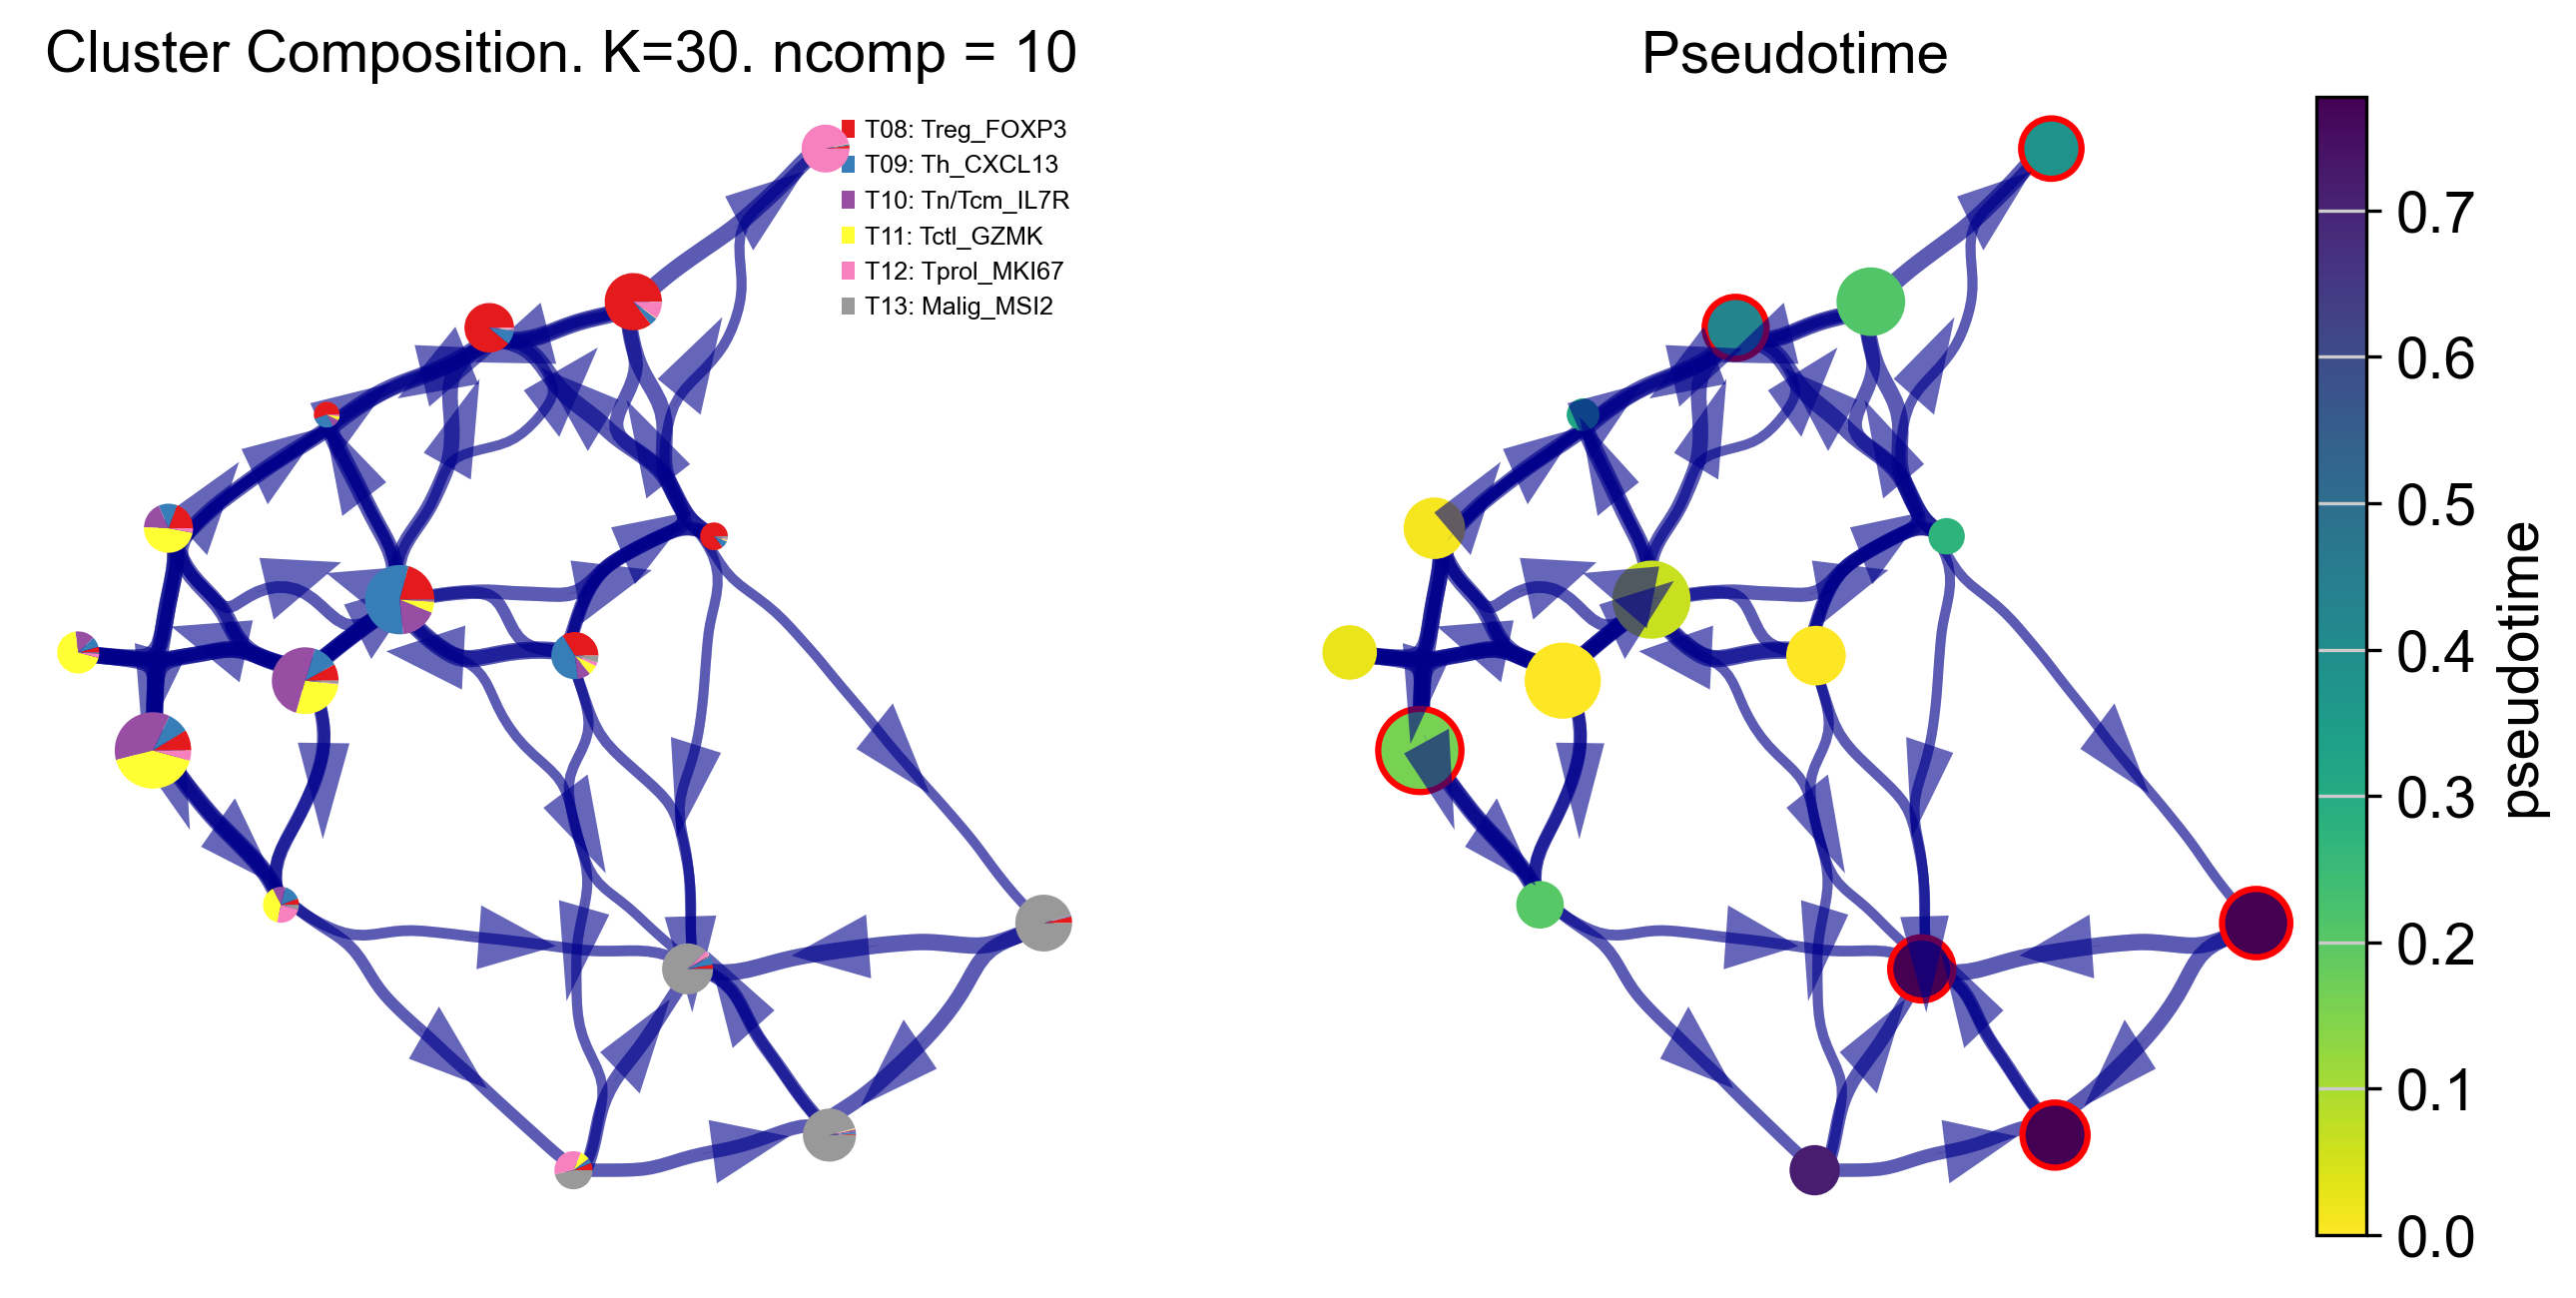

In [24]:
root = ['T10: Tn/Tcm_IL7R'] #for reproducibility, we set the root here. the group level root assignment must correspond to a label that exists in the True-label parameter (must be passed inside a list). For autodetection based on rna-velocity it can be left as None. A single cell index can also be passed e.g. [256], means the 256th cell will be used as a root. Since we will be using the velocity matrices (see below), Via 2.0 will suggest a list of likely root cell states that the user can decide to choose between. It is helpful to examine the top 5 suggested roots and choose the one that seems most reasonable. Note in the output that Via 2.0's suggestions are almost all in the epibliast or Primitive streak state 
adata_CD4T = adata_subT[adata_subT.obs['CellStateLabels'].isin(['T08: Treg_FOXP3',
       'T09: Th_CXCL13', 'T10: Tn/Tcm_IL7R', 'T11: Tctl_GZMK',
       'T12: Tprol_MKI67', 'T13: Malig_MSI2'])]
neighboring_terminal_states_threshold = 4
max_visual_outgoing_edges = 10#5 #used in differentiation flow chart plots
time_series = True
parc_numeric_cluster_labels = [i for i in adata_CD4T.obs['leiden-T']]
cluster_celltype_label = [i for i in adata_CD4T.obs['CellStateLabels']]
use_velocity = False
velo_weight = 0.5
vCD4T = via.VIA(adata_CD4T.obsm['X_pca_harmony'][:, 0:n_pcs], true_label = cluster_celltype_label,
        edgepruning_clustering_resolution=edgepruning_clustering_resolution,
        edgepruning_clustering_resolution_local=1, knn=knn, memory=memory,
        root_user=root, random_seed=random_seed,
        knn_sequential_reverse=knn_sequential,
        gene_matrix=gene_matrix, velocity_matrix=velocity_matrix,
        velo_weight=velo_weight,
        )
print(f'{datetime.now()}\tRun Via2.0')
vCD4T.run_VIA()
print(f'{datetime.now()}\tEnd Via2.0 computation')
print(f'{datetime.now()}\tPlot Via2.0 cluster graph')
f, ax, ax1=via.plot_piechart_viagraph(via_object=vCD4T, headwidth_arrow=0.2, show_legend=True, ax_text=False, pie_size_scale=0.6, cmap_piechart='Set1', 
                        highlight_terminal_clusters=True, size_node_notpiechart=0.8)
f.set_size_inches(10, 5)
f.savefig(f'{figPath}/FigS6h-CD4T.pdf')

2026-04-15 15:55:25.914432	Run Via2.0
2026-04-15 15:55:25.914572	Running VIA over input data of 22616 (samples) x 10 (features)
2026-04-15 15:55:25.914587	Knngraph has 30 neighbors
2026-04-15 15:55:32.093993	Finished global pruning of 30-knn graph used for clustering at level of 0.15. Kept 48.4 % of edges. 
2026-04-15 15:55:32.213892	Number of connected components used for clustergraph  is 1
2026-04-15 15:55:33.377287	Commencing community detection
2026-04-15 15:55:36.883264	Finished community detection. Found 39 clusters.
2026-04-15 15:55:36.889896	Merging 21 very small clusters (<10)
2026-04-15 15:55:36.894492	Finished detecting communities. Found 18 communities
2026-04-15 15:55:36.895792	Making cluster graph. Global cluster graph pruning level: 0.15
2026-04-15 15:55:36.959641	Graph has 1 connected components before pruning
2026-04-15 15:55:36.961499	Graph has 1 connected components after pruning
2026-04-15 15:55:36.961655	Graph has 1 connected components after reconnecting
2026-04-1

/home/rzh/miniconda3/lib/python3.11/site-packages/pyVIA/core.py:176: UserWarning: WARNING: Implicitly set node IDs to the canonical node ordering due to missing IDs field in the raw CSR npz file. This warning message can be suppressed by setting implicit_ids to True in the read_npz function call, or by setting the --implicit_ids flag in the CLI
  g.set_node_ids(node_ids=None,


  0%|          | 0/1300 [00:00<?, ?it/s]

memory for rw2 hittings times  2. Using rw2 based pt
2026-04-15 15:55:42.314557	Identifying terminal clusters corresponding to unique lineages...
2026-04-15 15:55:42.314594	Closeness:[0, 3, 4, 5, 8, 11, 16]
2026-04-15 15:55:42.314610	Betweenness:[0, 1, 3, 5, 6, 8, 13, 15, 16, 17]
2026-04-15 15:55:42.314619	Out Degree:[0, 3, 5, 8, 11, 16]
2026-04-15 15:55:42.314812	Cluster 3 had 3 or more neighboring terminal states [0, 8, 11] and so we removed cluster 0
2026-04-15 15:55:42.314847	We removed cluster 11 from the shortlist of terminal states
2026-04-15 15:55:42.314976	Terminal clusters corresponding to unique lineages in this component are [3, 5, 8, 16] 
2026-04-15 15:55:42.315001	Calculating lineage probability at memory 100


/home/rzh/miniconda3/lib/python3.11/site-packages/pyVIA/core.py:176: UserWarning: WARNING: Implicitly set node IDs to the canonical node ordering due to missing IDs field in the raw CSR npz file. This warning message can be suppressed by setting implicit_ids to True in the read_npz function call, or by setting the --implicit_ids flag in the CLI
  g.set_node_ids(node_ids=None,


...

2026-04-15 15:55:47.046887	Cluster or terminal cell fate 3 is reached 1000.0 times
2026-04-15 15:55:47.080091	Cluster or terminal cell fate 5 is reached 13.0 times
2026-04-15 15:55:47.102191	Cluster or terminal cell fate 8 is reached 1000.0 times
2026-04-15 15:55:47.133535	16 cluster/state is never reached. try increase number of KNN (which will increase number of edges) or try to increase the value of jac_std_global and cluster_graph_pruning which will lower edge pruning
2026-04-15 15:55:47.153180	There are (4) terminal clusters corresponding to unique lineages {3: 'T13: Malig_MSI2', 5: 'T12: Tprol_MKI67', 8: 'T13: Malig_MSI2', 16: 'T12: Tprol_MKI67'}
2026-04-15 15:55:47.153224	Begin projection of pseudotime and lineage likelihood


/home/rzh/miniconda3/lib/python3.11/site-packages/pyVIA/core.py:2479: RuntimeWarning: invalid value encountered in divide
  bp_array = bp_array / bp_array.sum(axis=1)[:, None]  # row normalization at the cluster level


2026-04-15 15:55:47.765683	Cluster graph layout based on forward biasing
2026-04-15 15:55:47.766954	Starting make edgebundle viagraph...
2026-04-15 15:55:47.766984	Make via clustergraph edgebundle
2026-04-15 15:55:47.937041	Hammer dims: Nodes shape: (18, 2) Edges shape: (112, 3)
2026-04-15 15:55:47.937945	Graph has 1 connected components before pruning
2026-04-15 15:55:47.939548	Graph has 5 connected components after pruning
2026-04-15 15:55:47.942930	Graph has 1 connected components after reconnecting
2026-04-15 15:55:47.943494	67.9% links trimmed from local pruning relative to start
2026-04-15 15:55:47.943525	74.1% links trimmed from global pruning relative to start
initial links 112 and final_links_n 36


/home/rzh/miniconda3/lib/python3.11/site-packages/scipy/sparse/_index.py:100: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/rzh/miniconda3/lib/python3.11/site-packages/pyVIA/plotting_via.py:3696: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the 

2026-04-15 15:55:47.981630	Time elapsed 19.4 seconds
2026-04-15 15:55:47.982367	End Via2.0 computation
2026-04-15 15:55:47.982509	Plot Via2.0 cluster graph
tune edges False


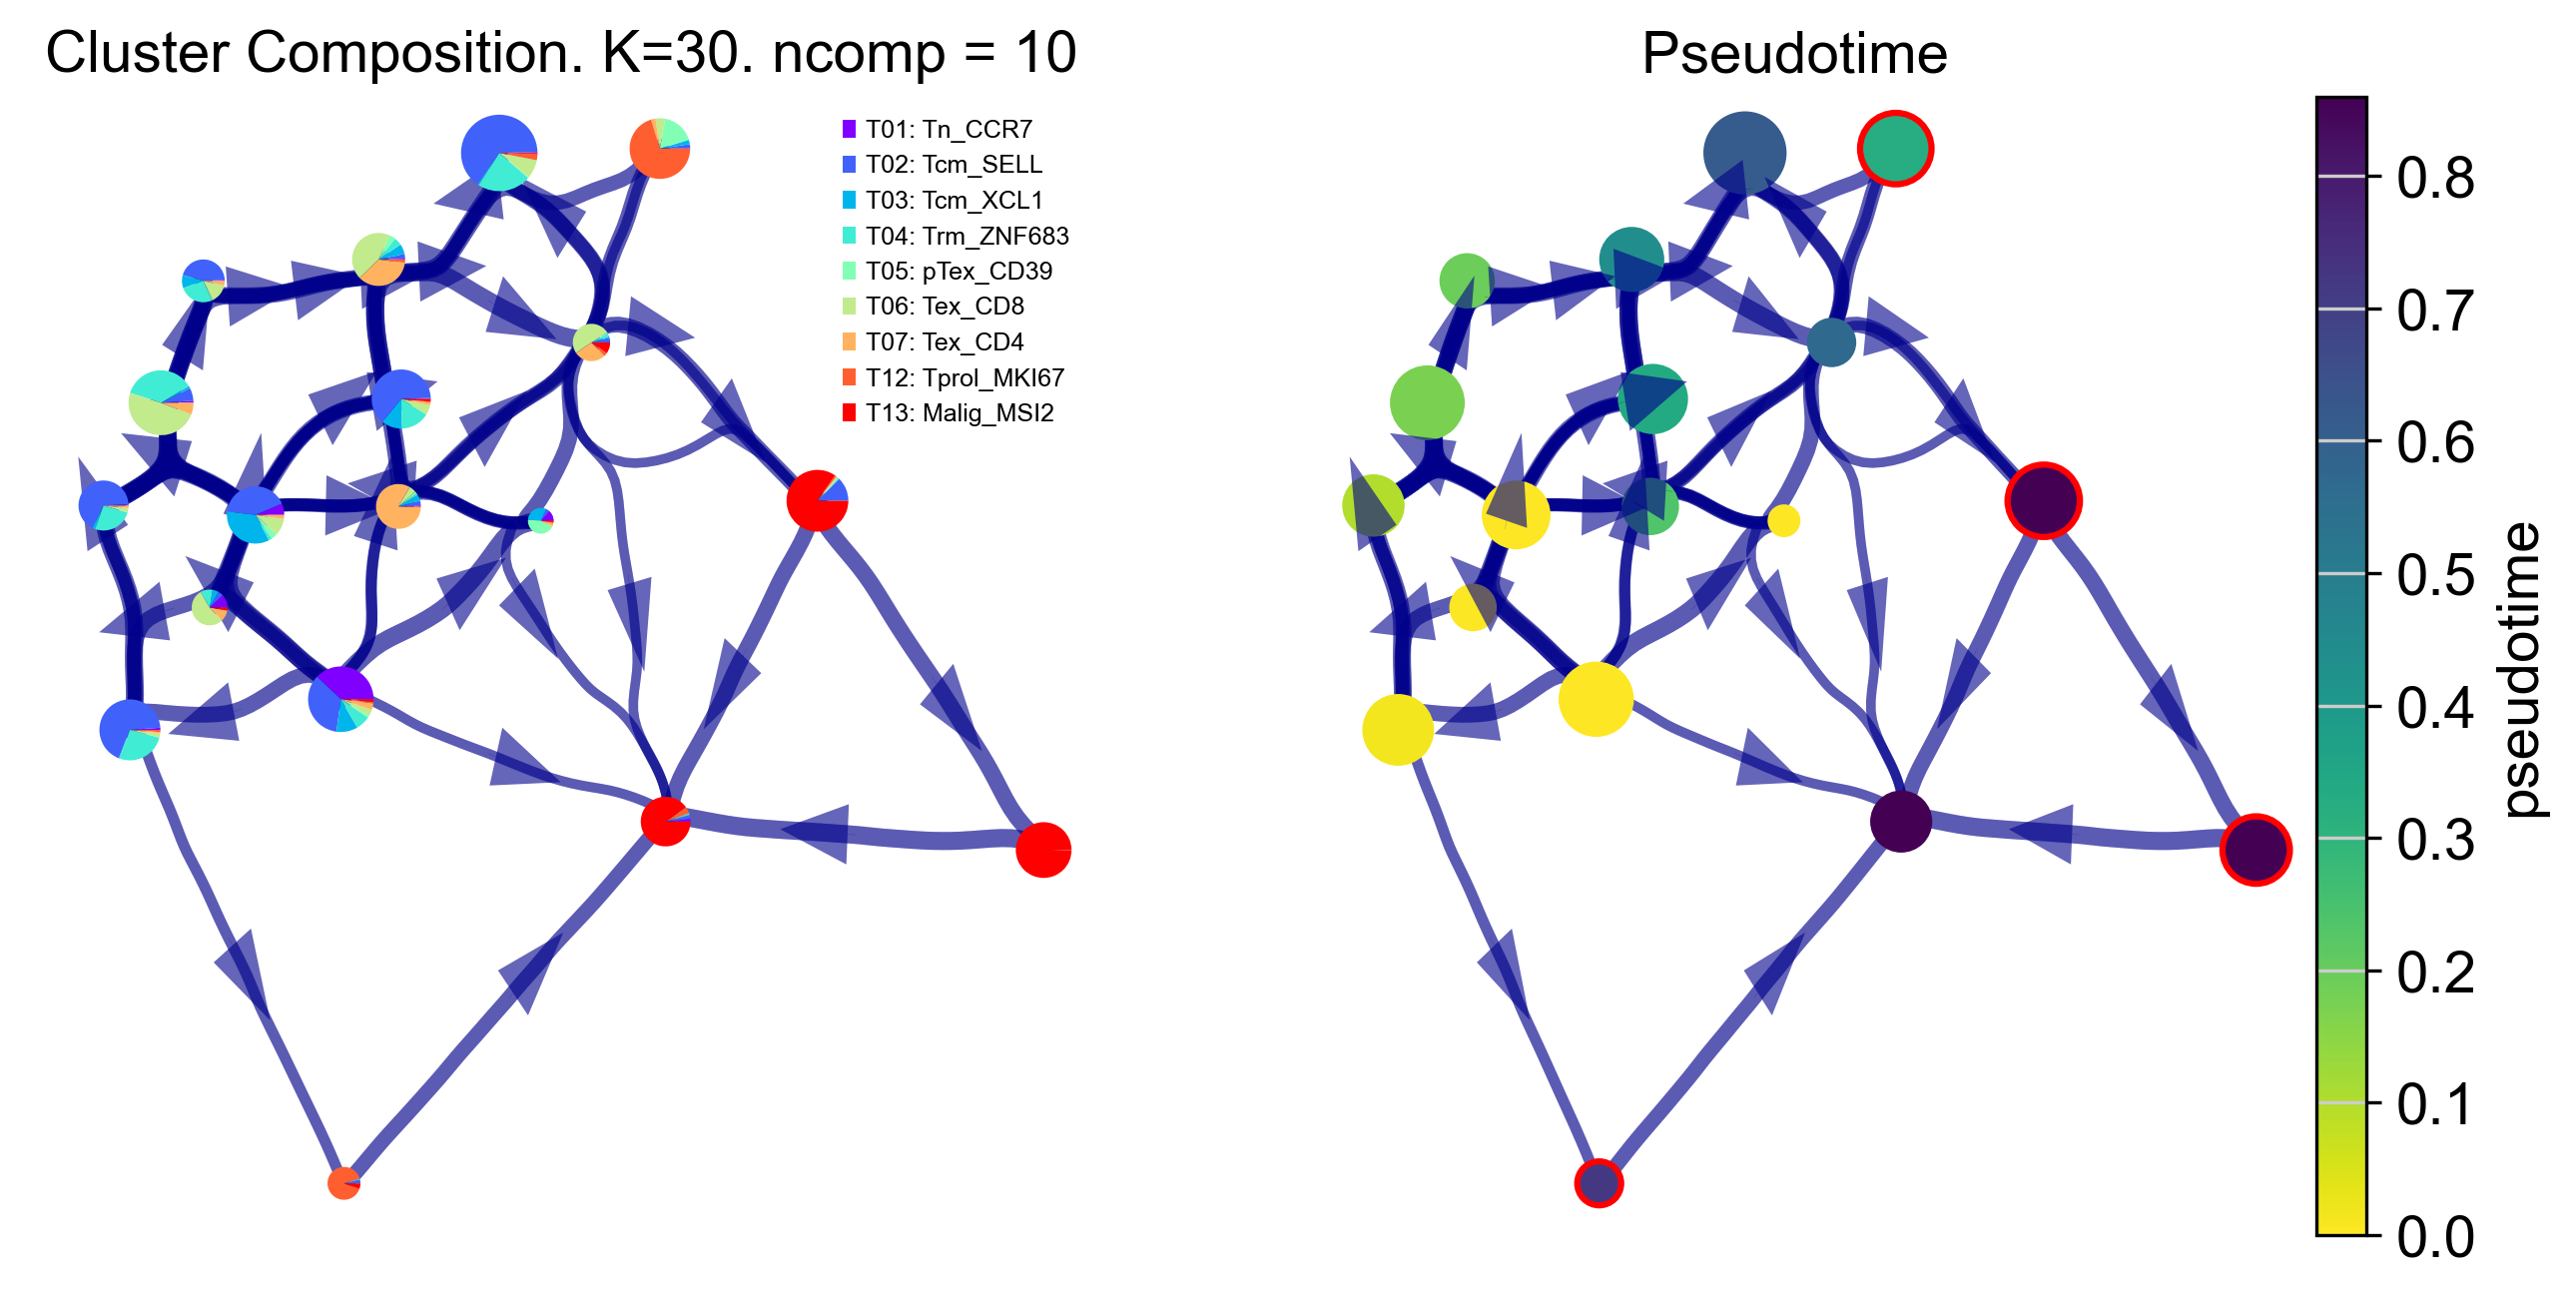

In [25]:
root = ['T01: Tn_CCR7'] #for reproducibility, we set the root here. the group level root assignment must correspond to a label that exists in the True-label parameter (must be passed inside a list). For autodetection based on rna-velocity it can be left as None. A single cell index can also be passed e.g. [256], means the 256th cell will be used as a root. Since we will be using the velocity matrices (see below), Via 2.0 will suggest a list of likely root cell states that the user can decide to choose between. It is helpful to examine the top 5 suggested roots and choose the one that seems most reasonable. Note in the output that Via 2.0's suggestions are almost all in the epibliast or Primitive streak state 
adata_CD8T = adata_subT[adata_subT.obs['CellStateLabels'].isin(['T01: Tn_CCR7', 'T02: Tcm_SELL', 'T03: Tcm_XCL1', 'T04: Trm_ZNF683',
       'T05: pTex_CD39', 'T06: Tex_CD8', 'T07: Tex_CD4', 'T12: Tprol_MKI67', 'T13: Malig_MSI2'])]
neighboring_terminal_states_threshold = 4
max_visual_outgoing_edges = 10 #5 #used in differentiation flow chart plots
time_series = True
parc_numeric_cluster_labels = [i for i in adata_CD8T.obs['leiden-T']]
cluster_celltype_label = [i for i in adata_CD8T.obs['CellStateLabels']]
use_velocity = False
velo_weight = 0.5
vCD8T = via.VIA(adata_CD8T.obsm['X_pca_harmony'][:, 0:n_pcs], true_label = cluster_celltype_label,
        edgepruning_clustering_resolution=edgepruning_clustering_resolution,
        edgepruning_clustering_resolution_local=1, knn=knn, memory=memory,
        root_user=root, random_seed=random_seed,
        knn_sequential_reverse=knn_sequential,
        gene_matrix=gene_matrix, velocity_matrix=velocity_matrix,
        velo_weight=velo_weight,
        )
print(f'{datetime.now()}\tRun Via2.0')
vCD8T.run_VIA()
print(f'{datetime.now()}\tEnd Via2.0 computation')
print(f'{datetime.now()}\tPlot Via2.0 cluster graph')

# f, ax, ax1=via.plot_piechart_viagraph(via_object=v0, cmap_piechart='viridis_r', cmap='viridis_r',  reference_labels=cluster_celltype_label, headwidth_arrow=0.4,
#                         highlight_terminal_clusters=True, show_legend=True)
# f.set_size_inches(10, 5)
f, ax, ax1=via.plot_piechart_viagraph(via_object=vCD8T, 
                                      headwidth_arrow=0.2, 
                                      show_legend=True, 
                                      ax_text=False, 
                                      pie_size_scale=0.6, 
                        highlight_terminal_clusters=True, size_node_notpiechart=0.8)
f.set_size_inches(10, 5)
f.savefig(f'{figPath}/FigS6h-CD8T.pdf')